In [ ]:
# Proyecto: Optimizacion
# Sergio Raul Bonilla Alejo
# Dr. German Pineda
# Fecha: 26-Jun-2026

# **Notebook 3.1: Optimización I**

Este notebook muestra una animación de descenso por gradiente sobre un modelo tipo Gabor 1D.

**Objetivo:** observar cómo cambian los parámetros, la pérdida y el ajuste del modelo durante el entrenamiento.

Modelo usado:

$$
y(x)=\sin(z)\exp(-z^2/8),\qquad z=\phi_0+0.06\phi_1x
$$

Actualización:

$$
\phi_{t+1}=\phi_t-\alpha
abla_\phi L(\phi_t)
$$


In [ ]:
# Animación: optimización de un modelo tipo Gabor 1D con descenso por gradiente de paso fijo
#   y(x) = sin(z) * exp(-z^2/8),  z = phi0 + 0.06*phi1*x

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- 1) Datos sintéticos ---
true = dict(
    phi0=3.0,   # desplazamiento tipo centro
    phi1=15.0,   # escala tipo frecuencia
)

def gabor(x, phi0, phi1):
    z = phi0 + 0.06*phi1 * x
    return np.sin(z) * np.exp(-(z**2) / 8.0)

n = 50
x = np.linspace(-15.0, 15.0, n)

y_clean = gabor(x, true["phi0"], true["phi1"])
y = y_clean + 0.1*np.random.randn(n)
y_true = gabor(x, true["phi0"], true["phi1"])
# --- 2) Modelo y pérdida ---
def predict(phi0, phi1, x):
    return gabor(x, phi0, phi1)

def mse_loss(phi0, phi1, x, y):
    r = predict(phi0, phi1, x) - y
    return 0.5 * np.mean(r**2)

def grad_mse(phi0, phi1, x, y):
    # yhat = sin(z)*exp(-z^2/8),  z = phi0 + 0.06*phi1*x
    z = phi0 + 0.06*phi1*x
    e = np.exp(-(z**2) / 8.0)
    s = np.sin(z)
    c = np.cos(z)

    yhat = s * e
    r = yhat - y

    # Derivada: dy/dz = e*(cos(z) - (z/4)*sin(z))
    dy_dz = e * (c - (z/4.0)*s)

    # Derivadas internas: dz/dphi0 = 1, dz/dphi1 = 0.06*x
    dy_dphi0 = dy_dz
    dy_dphi1 = dy_dz * (0.06*x)

    g0 = np.mean(r * dy_dphi0)
    g1 = np.mean(r * dy_dphi1)
    return np.array([g0, g1])

plt.style.use("classic")

# Aumentar el límite de memoria para insertar la animación
plt.rcParams["animation.embed_limit"] = 100.0

# --- 3) Ejecutar descenso por gradiente y guardar historial ---
# TODO: probar distintos puntos iniciales y tasas de aprendizaje para observar convergencia o divergencia
phi = np.array([-2.0, 5.0], dtype=float)   # [phi0, phi1] initial guess
history = [phi.copy()]
loss_hist = [mse_loss(phi[0], phi[1], x, y)]

n_steps = 120
lr = 8.0         # try 0.2..10.0 if it diverges/converges too slowly

for _ in range(n_steps):
    g = grad_mse(phi[0], phi[1], x, y)

    phi = phi - lr * g

    history.append(phi.copy())
    loss_hist.append(mse_loss(phi[0], phi[1], x, y))

history = np.array(history)

# --- 4) Precalcular la superficie de pérdida para el gráfico de contornos ---
phi0_min, phi0_max = -10.0, 10.0
phi1_min, phi1_max = 0.0, 25.0

P0 = np.linspace(phi0_min, phi0_max, 100)
P1 = np.linspace(phi1_min, phi1_max, 100)
PP0, PP1 = np.meshgrid(P0, P1)

# Superficie de pérdida vectorizada
z = PP0[None, :, :] + 0.06*PP1[None, :, :]*x[:, None, None]
yhat_grid = np.sin(z) * np.exp(-(z**2) / 8.0)
r_grid = yhat_grid - y[:, None, None]
L = 0.5 * np.mean(r_grid**2, axis=0)

# --- 5) Construir la animación con dos paneles ---
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Izquierda: contornos de pérdida y trayectoria de parámetros
cf = axL.contourf(PP0, PP1, L, levels=40, cmap="viridis", alpha=0.75)
axL.contour(PP0, PP1, L, levels=18, cmap="viridis", linewidths=1, alpha=1.0)
axL.set_title(r"Superficie de pérdida  L($\phi_0$, $\phi_1$)")
axL.set_xlabel(r"$\phi_0$")
axL.set_ylabel(r"$\phi_1$")
axL.set_xlim(phi0_min, phi0_max)
axL.set_ylim(phi1_min, phi1_max)
cbar = fig.colorbar(cf, ax=axL, fraction=0.046, pad=0.04)
cbar.set_label("pérdida")

# Marcar parámetros verdaderos
axL.scatter([true["phi0"]], [true["phi1"]], marker="+", s=200, linewidths=3, c="red")

path_line, = axL.plot([], [], lw=3, color="orange", alpha=0.8)
point_scatter = axL.scatter([], [], s=120, c="orange")

# Derecha: datos y curva de ajuste actual
axR.scatter(x, y, s=70)
axR.plot(x, y_true, lw=2, color="red", alpha=0.5,linestyle="--")
axR.set_ylim(-1, 1)
axR.set_xlim(-15, 15)
axR.set_xlabel(r"Input, $x$")
axR.set_ylabel(r"Output, $y$")

xx = np.linspace(x.min(), x.max(), 800)
fit_line, = axR.plot([], [], lw=3, color="orange", alpha=0.8)

loss_text = axR.text(0.02, 0.98, "", transform=axR.transAxes, va="top")

def init():
    path_line.set_data([], [])
    point_scatter.set_offsets(np.empty((0, 2)))
    fit_line.set_data([], [])
    loss_text.set_text("")
    return path_line, point_scatter, fit_line, loss_text

def update(frame):
    phis = history[:frame+1]
    phi0, phi1 = history[frame]

    # Actualizaciones del panel izquierdo
    path_line.set_data(phis[:, 0], phis[:, 1])
    point_scatter.set_offsets(np.array([[phi0, phi1]]))

    # Actualizaciones del panel derecho
    yy = gabor(xx, phi0, phi1)
    fit_line.set_data(xx, yy)

    cur_loss = mse_loss(phi0, phi1, x, y)
    loss_text.set_text(fr"$\phi_0$={phi0:.3f}, $\phi_1$={phi1:.3f}  loss={cur_loss:.5f}")

    return path_line, point_scatter, fit_line, loss_text

anim = FuncAnimation(
    fig, update, frames=len(history),
    init_func=init, interval=120, blit=True, repeat=True,
)

plt.close(fig)
HTML(anim.to_jshtml())

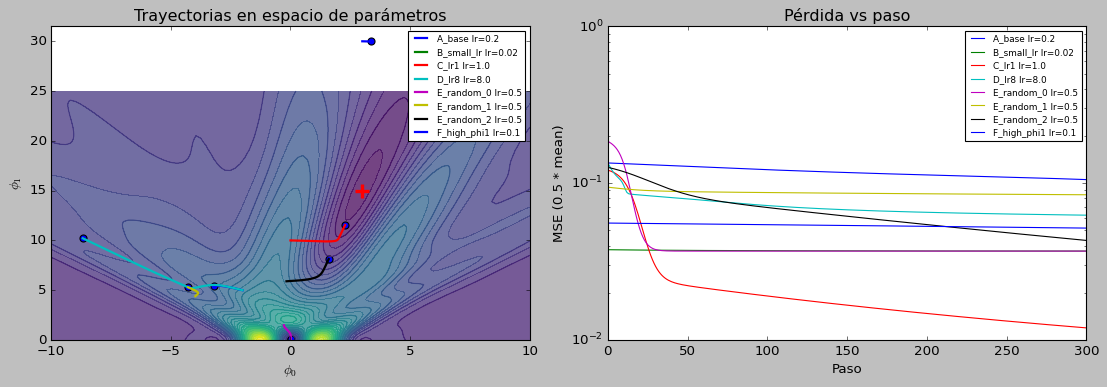

In [ ]:
# Celda: Experimentos de descenso por gradiente (pegar en Colab)
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Datos sintéticos (Copied from cell 092fe3f5) ---
true = dict(
    phi0=3.0,   # desplazamiento tipo centro
    phi1=15.0,   # escala tipo frecuencia
)

def gabor(x, phi0, phi1):
    z = phi0 + 0.06*phi1 * x
    return np.sin(z) * np.exp(-(z**2) / 8.0)

n = 50
x = np.linspace(-15.0, 15.0, n)

y_clean = gabor(x, true["phi0"], true["phi1"])
y = y_clean + 0.1*np.random.randn(n)
y_true = gabor(x, true["phi0"], true["phi1"])

# --- 2) Modelo y pérdida (Copied from cell 092fe3f5) ---
def predict(phi0, phi1, x):
    return gabor(x, phi0, phi1)

def mse_loss(phi0, phi1, x, y):
    r = predict(phi0, phi1, x) - y
    return 0.5 * np.mean(r**2)

def grad_mse(phi0, phi1, x, y):
    # yhat = sin(z)*exp(-z^2/8),  z = phi0 + 0.06*phi1*x
    z = phi0 + 0.06*phi1*x
    e = np.exp(-(z**2) / 8.0)
    s = np.sin(z)
    c = np.cos(z)

    yhat = s * e
    r = yhat - y

    # Derivada: dy/dz = e*(cos(z) - (z/4)*sin(z))
    dy_dz = e * (c - (z/4.0)*s)

    # Derivadas internas: dz/dphi0 = 1, dz/dphi1 = 0.06*x
    dy_dphi0 = dy_dz
    dy_dphi1 = dy_dz * (0.06*x)

    g0 = np.mean(r * dy_dphi0)
    g1 = np.mean(r * dy_dphi1)
    return np.array([g0, g1])

# --- 4) Precalcular la superficie de pérdida para el gráfico de contornos (Copied from cell 092fe3f5) ---
phi0_min, phi0_max = -10.0, 10.0
phi1_min, phi1_max = 0.0, 25.0

P0 = np.linspace(phi0_min, phi0_max, 100)
P1 = np.linspace(phi1_min, phi1_max, 100)
PP0, PP1 = np.meshgrid(P0, P1)

# Superficie de pérdida vectorizada
z = PP0[None, :, :] + 0.06*PP1[None, :, :]*x[:, None, None]
yhat_grid = np.sin(z) * np.exp(-(z**2) / 8.0)
r_grid = yhat_grid - y[:, None, None]
L = 0.5 * np.mean(r_grid**2, axis=0)

# Asume que gabor, mse_loss, grad_mse, x, y, y_true ya están definidos en el notebook.
# Si no, vuelve a ejecutar las celdas previas donde se definen.

def run_gd(phi_init, lr, n_steps=200):
    phi = np.array(phi_init, dtype=float)
    history = [phi.copy()]
    loss_hist = [mse_loss(phi[0], phi[1], x, y)]
    for _ in range(n_steps):
        g = grad_mse(phi[0], phi[1], x, y)
        phi = phi - lr * g
        history.append(phi.copy())
        loss_hist.append(mse_loss(phi[0], phi[1], x, y))
        # Detectar NaNs o valores enormes para cortar
        if not np.isfinite(loss_hist[-1]) or loss_hist[-1] > 1e6:
            print("Interrumpido: pérdida no finita o demasiado grande en paso", len(loss_hist)-1)
            break
    return np.array(history), np.array(loss_hist)

def plot_results(all_results, true_params=None):
    # all_results: list of dicts {'label','history','loss','lr','phi_init'}
    fig, axes = plt.subplots(1,2, figsize=(14,5))
    axL, axR = axes
    # Contorno de pérdida (si L ya fue calculada en el notebook, usarlo)
    try:
        axL.contourf(PP0, PP1, L, levels=40, cmap='viridis', alpha=0.75)
        axL.contour(PP0, PP1, L, levels=18, cmap='viridis', linewidths=1, alpha=1.0)
    except NameError:
        axL.set_facecolor('#f0f0f0')
    axL.set_xlabel(r'$\phi_0$'); axL.set_ylabel(r'$\phi_1$'); axL.set_title('Trayectorias en espacio de parámetros')
    if true_params is not None:
        axL.scatter([true_params['phi0']], [true_params['phi1']], marker='+', s=150, c='red', linewidths=3)
    # Dibujar trayectorias
    for res in all_results:
        hist = res['history']
        axL.plot(hist[:,0], hist[:,1], lw=2, label=f"{res['label']} lr={res['lr']}")
        axL.scatter(hist[-1,0], hist[-1,1], s=40)
    axL.legend(fontsize=8)

    # Pérdida vs paso
    axR.set_title('Pérdida vs paso')
    axR.set_xlabel('Paso'); axR.set_ylabel('MSE (0.5 * mean)')
    for res in all_results:
        axR.plot(res['loss'], label=f"{res['label']} lr={res['lr']}")
    axR.set_yscale('log')
    axR.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# Definir experimentos sugeridos
experiments = [
    {'label':'A_base', 'phi_init':[-2.0, 5.0], 'lr':0.2},
    {'label':'B_small_lr', 'phi_init':[0.0, 0.0], 'lr':0.02},
    {'label':'C_lr1', 'phi_init':[0.0, 10.0], 'lr':1.0},
    {'label':'D_lr8', 'phi_init':[-2.0, 5.0], 'lr':8.0},
    {'label':'E_random', 'phi_init':None, 'lr':0.5},
    {'label':'F_high_phi1', 'phi_init':[3.0, 30.0], 'lr':0.1},
]

results = []
for exp in experiments:
    if exp['phi_init'] is None:
        # varios inicios aleatorios para E
        for i in range(3):
            phi0 = np.random.randn()*2.0
            phi1 = np.abs(np.random.randn()*8.0)  # phi1 positivo en este problema
            hist, loss = run_gd([phi0, phi1], exp['lr'], n_steps=300)
            results.append({'label':f"{exp['label']}_{i}", 'history':hist, 'loss':loss, 'lr':exp['lr'], 'phi_init':[phi0,phi1]})
    else:
        hist, loss = run_gd(exp['phi_init'], exp['lr'], n_steps=300)
        results.append({'label':exp['label'], 'history':hist, 'loss':loss, 'lr':exp['lr'], 'phi_init':exp['phi_init']})

# Mostrar resultados
plot_results(results, true_params=true)
